# TRIBE Validation Analysis (v3)

**What changed from v2:** Baseline is now `log_followers + duration` only (no caption embeddings). Captions added 384 noisy dims that hurt the baseline at n=61. This v3 isolates 'do TRIBE features add value above pure creator metadata' — a cleaner test.

**Outputs (saved to `data/analysis_outputs/`):**
1. `headline_auc.txt` — baseline vs baseline+TRIBE AUC numbers
2. `diff_map.png` — viral-vs-dud cortical activation difference
3. `pca_by_vertical.png` — TRIBE feature PCA scatter colored by vertical
4. `top_rois.png` and `top_rois.csv` — brain regions most correlated with virality
5. `continuous_regression.png` — TRIBE prediction vs log(views)
6. `intent_vs_actual.txt` — intended vs auto-assigned label agreement

## 1. Setup

In [1]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score

PROJECT_ROOT = Path('..')
CSV_PATH = PROJECT_ROOT / 'data' / 'videos.csv'
FEATURES_DIR = PROJECT_ROOT / 'data' / 'features'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'analysis_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

np.random.seed(42)
RANDOM_STATE = 42

TRIBE_PCA_COMPONENTS = 30
LOGREG_C = 1.0      # back to default C=1 since baseline is now low-dim
RIDGE_ALPHA = 10.0

print('Setup OK')

Setup OK


## 2. Load data and features

In [2]:
meta = pd.read_csv(CSV_PATH)
available_npz = set(f.stem for f in FEATURES_DIR.glob('*.npz'))
meta['video_id'] = meta['video_id'].astype(str)
meta = meta[meta['video_id'].isin(available_npz)].copy().reset_index(drop=True)
print(f'Loaded {len(meta)} videos')

# Load fmri_preds and fusion_hidden
fmri_means = []
fusion_means = []
for vid in meta['video_id']:
    npz = np.load(FEATURES_DIR / f'{vid}.npz', allow_pickle=True)
    fmri_means.append(npz['fmri_preds'].mean(axis=0))
    fusion = npz['fusion_hidden']
    fusion_means.append(fusion.reshape(-1, fusion.shape[-1]).mean(axis=0))
fmri_means = np.stack(fmri_means)
fusion_means = np.stack(fusion_means)
print(f'fmri features:   {fmri_means.shape}')
print(f'fusion features: {fusion_means.shape}')

# Numeric baseline (NO captions in v3)
meta['log_followers'] = np.log1p(pd.to_numeric(meta['creator_followers_at_post'], errors='coerce').fillna(0))
meta['log_views'] = np.log1p(pd.to_numeric(meta['views_at_30d'], errors='coerce').fillna(0))
meta['duration_num'] = pd.to_numeric(meta['duration'], errors='coerce').fillna(0)

X_baseline = meta[['log_followers', 'duration_num']].values
print(f'\nX_baseline (log_followers + duration): {X_baseline.shape}')
print(f'X_baseline + TRIBE PCA-{TRIBE_PCA_COMPONENTS}: will be {X_baseline.shape[1] + TRIBE_PCA_COMPONENTS}')

print('\nLabel distribution:')
print(meta['label'].value_counts())

Loaded 69 videos
fmri features:   (69, 20484)
fusion features: (69, 1152)

X_baseline (log_followers + duration): (69, 2)
X_baseline + TRIBE PCA-30: will be 32

Label distribution:
label
dud      35
viral    26
mid       8
Name: count, dtype: int64


## 3. Headline AUC — three models compared

In [5]:
binary_mask = meta['label'].isin(['viral', 'dud'])
y = (meta.loc[binary_mask, 'label'] == 'viral').astype(int).values
Xb = X_baseline[binary_mask.values]
Xt_raw = fmri_means[binary_mask.values]

print(f'Binary task: n={len(y)}, viral={y.sum()}, dud={(1-y).sum()}\n')

def cv_auc_baseline(Xb, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    aucs = []
    for tr, te in skf.split(Xb, y):
        sc = StandardScaler()
        Xtr = sc.fit_transform(Xb[tr])
        Xte = sc.transform(Xb[te])
        clf = LogisticRegression(C=LOGREG_C, max_iter=5000, random_state=RANDOM_STATE)
        clf.fit(Xtr, y[tr])
        proba = clf.predict_proba(Xte)[:, 1]
        aucs.append(roc_auc_score(y[te], proba))
    return float(np.mean(aucs)), float(np.std(aucs))

def cv_auc_tribe_pca(Xb, Xt, y, n_components, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    aucs = []
    for tr, te in skf.split(Xb, y):
        tribe_sc = StandardScaler()
        Xt_tr = tribe_sc.fit_transform(Xt[tr])
        Xt_te = tribe_sc.transform(Xt[te])
        pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
        Xt_tr_pca = pca.fit_transform(Xt_tr)
        Xt_te_pca = pca.transform(Xt_te)
        X_tr = np.hstack([Xb[tr], Xt_tr_pca])
        X_te = np.hstack([Xb[te], Xt_te_pca])
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)
        clf = LogisticRegression(C=LOGREG_C, max_iter=5000, random_state=RANDOM_STATE)
        clf.fit(X_tr, y[tr])
        proba = clf.predict_proba(X_te)[:, 1]
        aucs.append(roc_auc_score(y[te], proba))
    return float(np.mean(aucs)), float(np.std(aucs))

auc_b_mean, auc_b_std = cv_auc_baseline(Xb, y)
auc_pca_mean, auc_pca_std = cv_auc_tribe_pca(Xb, Xt_raw, y, TRIBE_PCA_COMPONENTS)
delta_pca = auc_pca_mean - auc_b_mean

# Also test a few PCA sizes for sensitivity
print('Sensitivity: AUC vs # PCA components')
sensitivity = []
for k in [5, 10, 20, 30, 40]:    
    m, s = cv_auc_tribe_pca(Xb, Xt_raw, y, k)
    sensitivity.append((k, m, s))
    print(f'  PCA-{k:3d}: AUC = {m:.3f} ± {s:.3f}')

print(f'\nBaseline (log_followers + duration):')
print(f'  AUC = {auc_b_mean:.3f} ± {auc_b_std:.3f}\n')
print(f'Baseline + TRIBE PCA-{TRIBE_PCA_COMPONENTS}:')
print(f'  AUC = {auc_pca_mean:.3f} ± {auc_pca_std:.3f}')
print(f'  Delta vs baseline: {delta_pca:+.3f}')

with open(OUTPUT_DIR / 'headline_auc.txt', 'w') as f:
    f.write(f'Headline AUC (5-fold stratified CV)\n')
    f.write(f'n = {len(y)} (viral={y.sum()}, dud={(1-y).sum()})\n')
    f.write(f'LogisticRegression C={LOGREG_C}, PCA components={TRIBE_PCA_COMPONENTS}\n\n')
    f.write(f'Baseline (log_followers + duration):\n')
    f.write(f'  AUC = {auc_b_mean:.3f} +/- {auc_b_std:.3f}\n\n')
    f.write(f'Baseline + TRIBE PCA-{TRIBE_PCA_COMPONENTS}:\n')
    f.write(f'  AUC = {auc_pca_mean:.3f} +/- {auc_pca_std:.3f}\n')
    f.write(f'  Delta: {delta_pca:+.3f}\n\n')
    f.write(f'PCA sensitivity:\n')
    for k, m, s in sensitivity:
        f.write(f'  PCA-{k:3d}: AUC = {m:.3f} +/- {s:.3f}\n')
print(f'\nSaved {OUTPUT_DIR / "headline_auc.txt"}')

Binary task: n=61, viral=26, dud=35

Sensitivity: AUC vs # PCA components
  PCA-  5: AUC = 0.707 ± 0.087
  PCA- 10: AUC = 0.705 ± 0.102
  PCA- 20: AUC = 0.772 ± 0.150
  PCA- 30: AUC = 0.745 ± 0.161
  PCA- 40: AUC = 0.765 ± 0.128

Baseline (log_followers + duration):
  AUC = 0.790 ± 0.077

Baseline + TRIBE PCA-30:
  AUC = 0.745 ± 0.161
  Delta vs baseline: -0.045

Saved ../data/analysis_outputs/headline_auc.txt


## 4. Continuous regression on log(views)

Continuous regression (5-fold CV, n=69):
  Baseline:               Spearman rho = 0.580 (p = 0.0000)
  Baseline + TRIBE PCA:   Spearman rho = 0.563 (p = 0.0000)
  Delta:                  -0.017


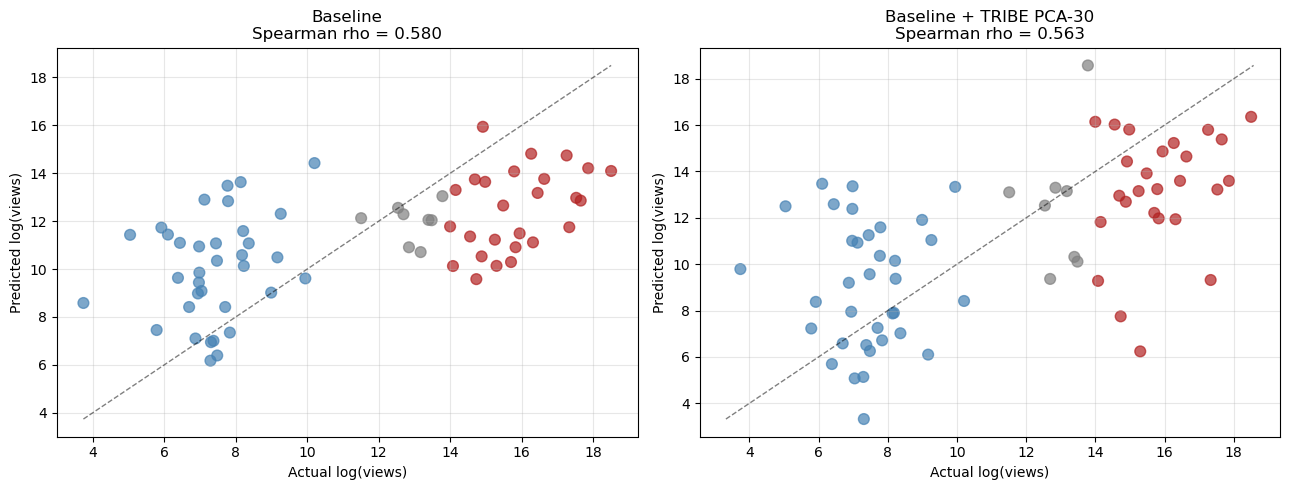

Saved ../data/analysis_outputs/continuous_regression.png


In [6]:
log_views = meta['log_views'].values
valid_mask = ~np.isnan(log_views) & (log_views > 0)
Xb_full = X_baseline[valid_mask]
Xt_full = fmri_means[valid_mask]
y_cont = log_views[valid_mask]

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
preds_baseline = np.zeros_like(y_cont)
preds_tribe = np.zeros_like(y_cont)

for tr, te in kf.split(Xb_full):
    sc_b = StandardScaler()
    Xb_tr = sc_b.fit_transform(Xb_full[tr])
    Xb_te = sc_b.transform(Xb_full[te])
    preds_baseline[te] = Ridge(alpha=RIDGE_ALPHA).fit(Xb_tr, y_cont[tr]).predict(Xb_te)

    tribe_sc = StandardScaler()
    Xt_tr = tribe_sc.fit_transform(Xt_full[tr])
    Xt_te = tribe_sc.transform(Xt_full[te])
    pca = PCA(n_components=TRIBE_PCA_COMPONENTS, random_state=RANDOM_STATE)
    Xt_tr_pca = pca.fit_transform(Xt_tr)
    Xt_te_pca = pca.transform(Xt_te)
    X_tr = np.hstack([Xb_full[tr], Xt_tr_pca])
    X_te = np.hstack([Xb_full[te], Xt_te_pca])
    sc_combined = StandardScaler()
    X_tr = sc_combined.fit_transform(X_tr)
    X_te = sc_combined.transform(X_te)
    preds_tribe[te] = Ridge(alpha=RIDGE_ALPHA).fit(X_tr, y_cont[tr]).predict(X_te)

rho_b, p_b = spearmanr(preds_baseline, y_cont)
rho_t, p_t = spearmanr(preds_tribe, y_cont)

print(f'Continuous regression (5-fold CV, n={len(y_cont)}):')
print(f'  Baseline:               Spearman rho = {rho_b:.3f} (p = {p_b:.4f})')
print(f'  Baseline + TRIBE PCA:   Spearman rho = {rho_t:.3f} (p = {p_t:.4f})')
print(f'  Delta:                  {rho_t - rho_b:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, label, rho_val in [
    (axes[0], preds_baseline, 'Baseline', rho_b),
    (axes[1], preds_tribe, f'Baseline + TRIBE PCA-{TRIBE_PCA_COMPONENTS}', rho_t),
]:
    colors_pts = ['firebrick' if l == 'viral' else 'steelblue' if l == 'dud' else 'gray'
                  for l in meta.loc[valid_mask, 'label']]
    ax.scatter(y_cont, preds, c=colors_pts, alpha=0.7, s=60)
    lims = [min(y_cont.min(), preds.min()), max(y_cont.max(), preds.max())]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1)
    ax.set_xlabel('Actual log(views)')
    ax.set_ylabel('Predicted log(views)')
    ax.set_title(f'{label}\nSpearman rho = {rho_val:.3f}')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'continuous_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {OUTPUT_DIR / "continuous_regression.png"}')

## 5. Diff map

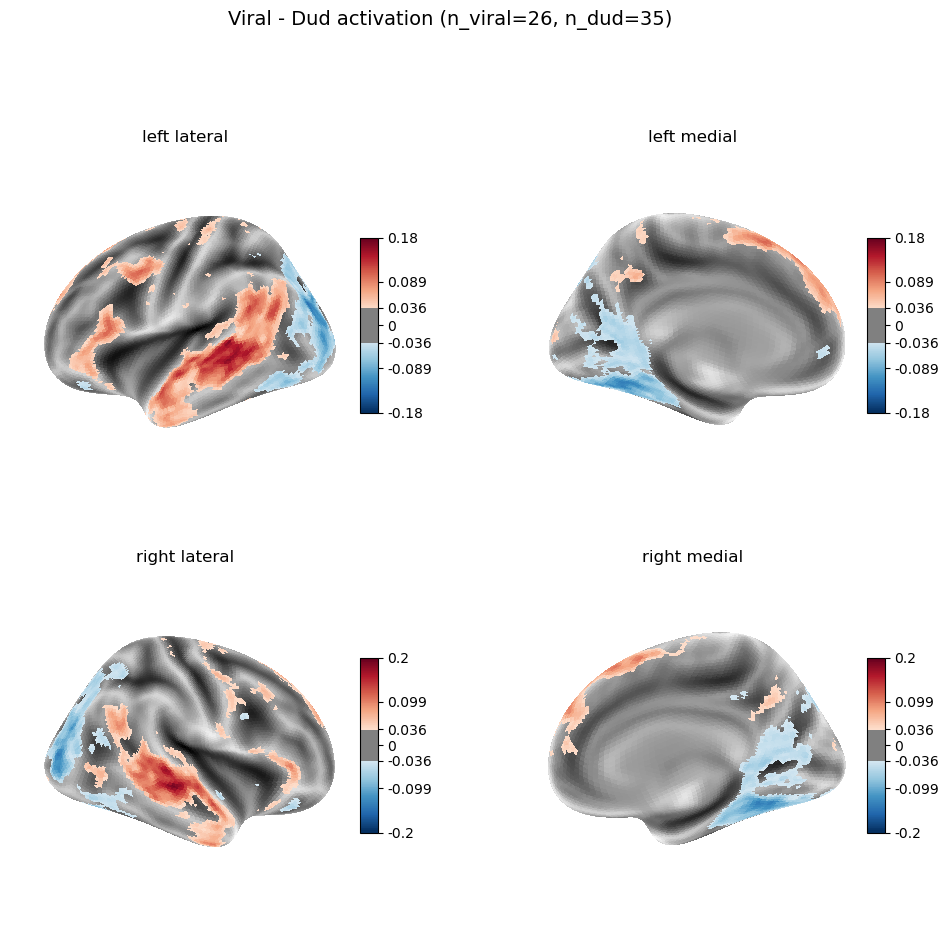

Saved ../data/analysis_outputs/diff_map.png


In [7]:
viral_idx = (meta['label'] == 'viral').values
dud_idx = (meta['label'] == 'dud').values
viral_mean = fmri_means[viral_idx].mean(axis=0)
dud_mean = fmri_means[dud_idx].mean(axis=0)
diff = viral_mean - dud_mean

from nilearn import plotting, datasets
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
n_per_hemi = 10242
left = diff[:n_per_hemi]
right = diff[n_per_hemi:]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={'projection': '3d'})
for ax, (hemi, data, mesh, view) in zip(
    axes.flat,
    [('left', left, fsaverage.infl_left, 'lateral'),
     ('left', left, fsaverage.infl_left, 'medial'),
     ('right', right, fsaverage.infl_right, 'lateral'),
     ('right', right, fsaverage.infl_right, 'medial')]):
    plotting.plot_surf_stat_map(
        mesh, data, hemi=hemi, view=view,
        bg_map=getattr(fsaverage, f'sulc_{hemi}'),
        colorbar=True, cmap='RdBu_r',
        threshold=np.percentile(np.abs(diff), 75),
        axes=ax, figure=fig, title=f'{hemi} {view}',
    )
plt.suptitle(f'Viral - Dud activation (n_viral={viral_idx.sum()}, n_dud={dud_idx.sum()})',
             fontsize=14, y=1.02)
plt.savefig(OUTPUT_DIR / 'diff_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {OUTPUT_DIR / "diff_map.png"}')

## 6. PCA scatter by vertical

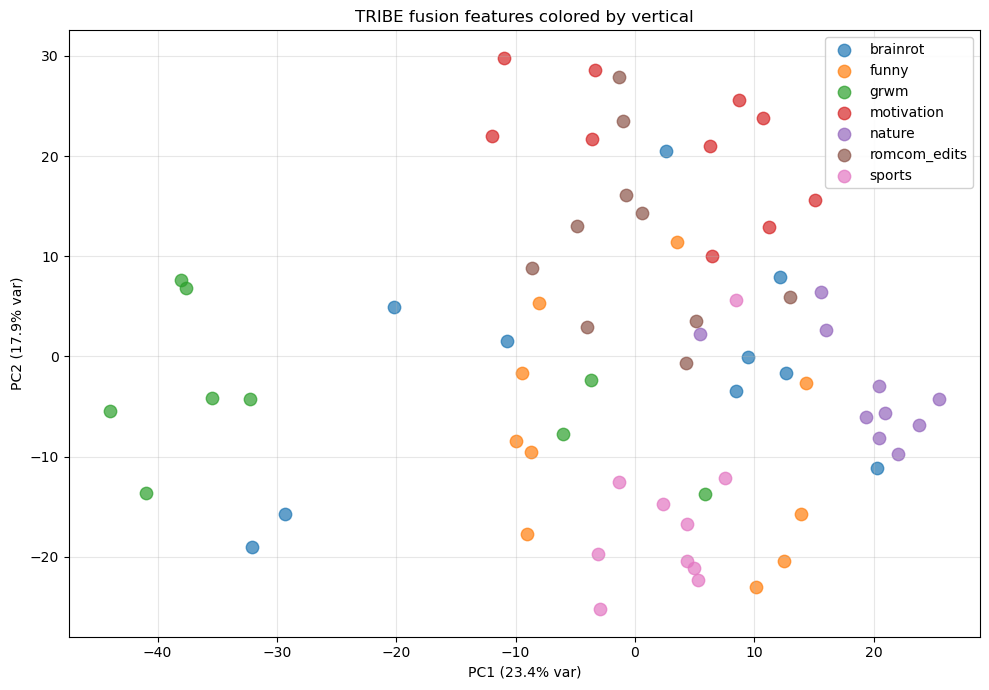

Saved ../data/analysis_outputs/pca_by_vertical.png
Total variance in 2 PCs: 41.2%


In [8]:
scaler = StandardScaler()
fusion_scaled = scaler.fit_transform(fusion_means)
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
fusion_2d = pca_2d.fit_transform(fusion_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
verticals = sorted(meta['vertical'].unique())
cmap = plt.get_cmap('tab10')
for i, v in enumerate(verticals):
    mask = (meta['vertical'] == v).values
    ax.scatter(fusion_2d[mask, 0], fusion_2d[mask, 1],
               label=v, alpha=0.7, s=80, c=[cmap(i)])
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('TRIBE fusion features colored by vertical')
ax.legend(loc='best', framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_by_vertical.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {OUTPUT_DIR / "pca_by_vertical.png"}')
print(f'Total variance in 2 PCs: {pca_2d.explained_variance_ratio_.sum():.1%}')

## 7. Top ROIs

[fetch_atlas_surf_destrieux] Dataset found in /Users/shloka/nilearn_data/destrieux_surface

/var/folders/2y/fhw6y9y153z6y_j9bthwbkfm0000gn/T/ipykernel_42101/210514615.py:2: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = nl_datasets.fetch_atlas_surf_destrieux()
/var/folders/2y/fhw6y9y153z6y_j9bthwbkfm0000gn/T/ipykernel_42101/210514615.py:2: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = nl_datasets.fetch_atlas_surf_destrieux()


Top 20 ROIs by |Spearman correlation| with log(views):
                        roi  spearman_rho   p_value   abs_rho
0       L_S_orbital_lateral      0.413043  0.000420  0.413043
1             L_G_front_sup      0.412788  0.000424  0.412788
2   L_G_front_inf-Opercular      0.405627  0.000545  0.405627
3    L_S_interm_prim-Jensen      0.403873  0.000579  0.403873
4     L_G_front_inf-Orbital      0.403361  0.000589  0.403361
5    L_G_front_inf-Triangul      0.399927  0.000663  0.399927
6     R_G_front_inf-Orbital      0.370588  0.001721  0.370588
7             R_G_front_sup      0.350895  0.003115  0.350895
8       L_G_temporal_middle      0.341798  0.004048  0.341798
9    L_Lat_Fis-ant-Horizont      0.337267  0.004598  0.337267
10              L_G_orbital      0.314943  0.008395  0.314943
11         L_S_temporal_sup      0.313445  0.008727  0.313445
12         L_G_front_middle      0.302009  0.011668  0.302009
13          R_Pole_temporal      0.289185  0.015952  0.289185
14      R_G_tem

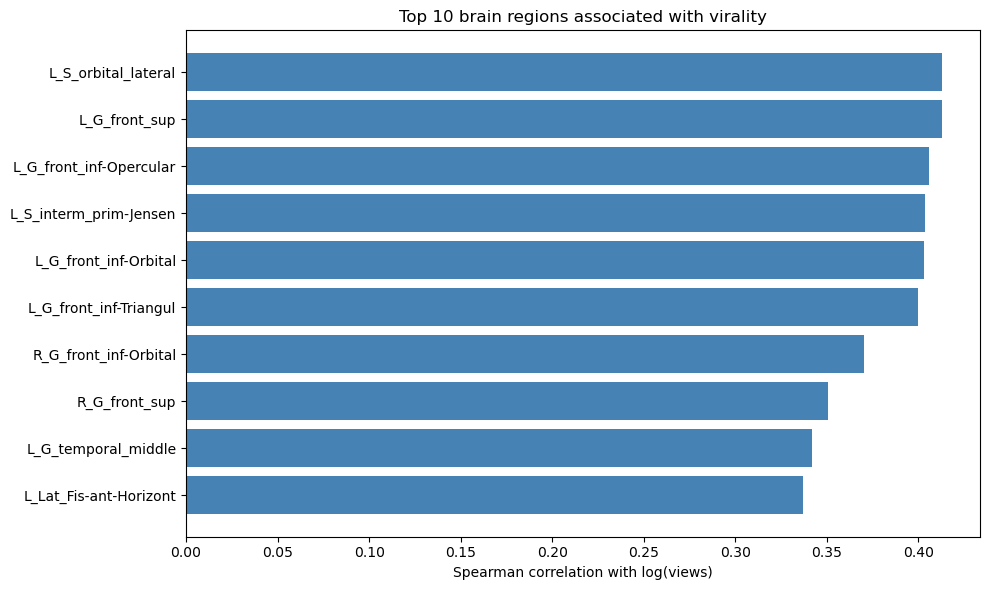


Saved ../data/analysis_outputs/top_rois.png and top_rois.csv


In [9]:
from nilearn import datasets as nl_datasets
destrieux = nl_datasets.fetch_atlas_surf_destrieux()
labels = [l.decode() if isinstance(l, bytes) else l for l in destrieux['labels']]
left_annot = destrieux['map_left']
right_annot = destrieux['map_right']

annot = np.concatenate([left_annot, right_annot])
hemi_labels = (['L_' + l for l in labels] + ['R_' + l for l in labels])
annot_offset = annot.copy()
annot_offset[len(left_annot):] = annot[len(left_annot):] + len(labels)

n_videos = fmri_means.shape[0]
n_rois = len(hemi_labels)
roi_activations = np.zeros((n_videos, n_rois))
for r in range(n_rois):
    mask = (annot_offset == r)
    if mask.sum() > 0:
        roi_activations[:, r] = fmri_means[:, mask].mean(axis=1)

log_views_arr = meta['log_views'].values
valid = ~np.isnan(log_views_arr) & (log_views_arr > 0)
rho = np.zeros(n_rois)
pval = np.ones(n_rois)
for r in range(n_rois):
    if roi_activations[valid, r].std() > 1e-9:
        rho[r], pval[r] = spearmanr(roi_activations[valid, r], log_views_arr[valid])

roi_df = pd.DataFrame({
    'roi': hemi_labels,
    'spearman_rho': rho,
    'p_value': pval,
    'abs_rho': np.abs(rho),
}).sort_values('abs_rho', ascending=False).head(20).reset_index(drop=True)

print('Top 20 ROIs by |Spearman correlation| with log(views):')
print(roi_df.to_string())
roi_df.to_csv(OUTPUT_DIR / 'top_rois.csv', index=False)

top10 = roi_df.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if r > 0 else 'firebrick' for r in top10['spearman_rho']]
ax.barh(top10['roi'], top10['spearman_rho'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Spearman correlation with log(views)')
ax.set_title('Top 10 brain regions associated with virality')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_rois.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved {OUTPUT_DIR / "top_rois.png"} and top_rois.csv')

## 8. Intent vs actual

In [10]:
intent_table = pd.crosstab(meta['intended_label'], meta['label'], margins=True)
print('Intended label vs actual label:')
print(intent_table)

intended_viral = meta['intended_label'] == 'viral'
intended_dud = meta['intended_label'] == 'not_viral'
viral_hit_rate = (meta.loc[intended_viral, 'label'] == 'viral').mean()
dud_hit_rate = (meta.loc[intended_dud, 'label'] == 'dud').mean()

print(f'\nIntended-viral hit rate: {viral_hit_rate:.1%}')
print(f'Intended-dud hit rate:   {dud_hit_rate:.1%}')

with open(OUTPUT_DIR / 'intent_vs_actual.txt', 'w') as f:
    f.write(intent_table.to_string())
    f.write(f'\n\nIntended-viral hit rate: {viral_hit_rate:.1%}\n')
    f.write(f'Intended-dud hit rate: {dud_hit_rate:.1%}\n')
print(f'\nSaved {OUTPUT_DIR / "intent_vs_actual.txt"}')

Intended label vs actual label:
label           dud  mid  viral  All
intended_label                      
not_viral        35    0      0   35
viral             0    8     26   34
All              35    8     26   69

Intended-viral hit rate: 76.5%
Intended-dud hit rate:   100.0%

Saved ../data/analysis_outputs/intent_vs_actual.txt


## 9. SUMMARY

In [11]:
print('=' * 60)
print('SUMMARY (v3 — baseline = log_followers + duration)')
print('=' * 60)
print(f'\nDataset: n={len(meta)} videos, 7 verticals')
print(f'  viral={(meta["label"]=="viral").sum()}, '
      f'mid={(meta["label"]=="mid").sum()}, '
      f'dud={(meta["label"]=="dud").sum()}')

print(f'\n--- HEADLINE: Binary classification (viral vs dud) ---')
print(f'  Baseline:                AUC = {auc_b_mean:.3f} ± {auc_b_std:.3f}')
print(f'  Baseline + TRIBE PCA-{TRIBE_PCA_COMPONENTS}: AUC = {auc_pca_mean:.3f} ± {auc_pca_std:.3f}  (delta {delta_pca:+.3f})')
print(f'\n  PCA sensitivity:')
for k, m, s in sensitivity:
    print(f'    PCA-{k:3d}: AUC = {m:.3f} ± {s:.3f}')

print(f'\n--- Continuous regression (Spearman rho) ---')
print(f'  Baseline:               {rho_b:.3f}')
print(f'  Baseline + TRIBE (PCA): {rho_t:.3f}  (delta {rho_t - rho_b:+.3f})')

print(f'\n--- Intent vs actual ---')
print(f'  Intended-viral hit rate: {viral_hit_rate:.1%}')
print(f'  Intended-dud hit rate:   {dud_hit_rate:.1%}')

print(f'\n--- Top 5 brain regions by |corr with log(views)| ---')
for _, row in roi_df.head(5).iterrows():
    print(f'  {row["roi"]}: rho = {row["spearman_rho"]:+.3f} (p = {row["p_value"]:.3f})')

SUMMARY (v3 — baseline = log_followers + duration)

Dataset: n=69 videos, 7 verticals
  viral=26, mid=8, dud=35

--- HEADLINE: Binary classification (viral vs dud) ---
  Baseline:                AUC = 0.790 ± 0.077
  Baseline + TRIBE PCA-30: AUC = 0.745 ± 0.161  (delta -0.045)

  PCA sensitivity:
    PCA-  5: AUC = 0.707 ± 0.087
    PCA- 10: AUC = 0.705 ± 0.102
    PCA- 20: AUC = 0.772 ± 0.150
    PCA- 30: AUC = 0.745 ± 0.161
    PCA- 40: AUC = 0.765 ± 0.128

--- Continuous regression (Spearman rho) ---
  Baseline:               0.580
  Baseline + TRIBE (PCA): 0.563  (delta -0.017)

--- Intent vs actual ---
  Intended-viral hit rate: 76.5%
  Intended-dud hit rate:   100.0%

--- Top 5 brain regions by |corr with log(views)| ---
  L_S_orbital_lateral: rho = +0.413 (p = 0.000)
  L_G_front_sup: rho = +0.413 (p = 0.000)
  L_G_front_inf-Opercular: rho = +0.406 (p = 0.001)
  L_S_interm_prim-Jensen: rho = +0.404 (p = 0.001)
  L_G_front_inf-Orbital: rho = +0.403 (p = 0.001)
